In [1]:
# Forward function
from rhythmic_sharing import RhythmicNetwork

# network = RhythmicNetwork(
#     dt=1,
#     input_dims=x.shape[0],
#     spectral_radius=0.7,
#     input_weight=1.0,
#     average_degree_nodes=8,
#     num_nodes=256,
#     leakage=0.5
# )

def rhythmic_forward(network, x, omega, eps=None):
    # print(network, x, omega)
    
    network.delete_history_and_update_natural_frequencies(omega)
    network.train(x)

    if eps is not None:
        network.epsilon1 = eps[0]
        network.epsilon2 = eps[0]
    
    return network.node_states_history[-1], network.get_natural_frequencies()

In [2]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import optax

In [3]:
def init_mlp_params(key, sizes):
    """
    Initializes parameters for a multi-layer perceptron (MLP).
    
    Args:
    key (int): Random seed for parameter initialization.
    sizes (list): List of integers representing the sizes of each layer.
    
    Returns:
    list: A list of dictionaries containing weights ('W') and biases ('b') for each layer.
    """
    key = jax.random.PRNGKey(key)
    keys = jax.random.split(key, len(sizes) - 1)
    params = []
    for k, (in_dim, out_dim) in zip(keys, zip(sizes[:-1], sizes[1:])):
        weight_key, bias_key = jax.random.split(k)
        W = jax.random.normal(weight_key, (in_dim, out_dim)) * jnp.sqrt(2 / in_dim)
        b = jnp.zeros((out_dim,))
        params.append({'W': W, 'b': b})
    return params

@jax.jit
def forward_readout_tanh(X, readout):
    """
    Performs a forward pass through a readout MLP with Tanh activation.
    
    Args:
    X (jax.numpy.ndarray): Input data.
    readout (list): List of layer parameters (weights and biases).
    
    Returns:
    jax.numpy.ndarray: Output of the readout MLP.
    """
    *hidden, last = readout
    for layer in hidden:
        X = jax.nn.tanh(X @ layer['W'] + layer['b'])
    return X @ last['W'] + last['b']


@jax.jit
def init_grad(params):
    """
    Initializes gradients for a parameter tree with zeros.
    
    Args:
    params (dict): Parameter tree.
    
    Returns:
    dict: Gradient tree initialized with zeros.
    """
    return jax.tree.map(lambda p: jnp.zeros(shape=(p.shape)), params)


@jax.jit
def get_perturbations(theta,epsilon,pert_key):
    """
    Generates random perturbations for parameters.
    
    Args:
    theta (dict): Parameter tree.
    epsilon (float): Perturbation magnitude.
    pert_key (int): Random seed for perturbation generation.
    
    Returns:
    dict: Perturbation tree.
    """
    key = jax.random.PRNGKey(pert_key, impl=None)
    return jax.tree.map(
        lambda p: jax.random.choice(key, jnp.array([-1,1])*epsilon, shape=(p.shape)), theta
    )

# @jax.jit
# def collect_grad(perts,delta_c,eta,G):
#     """
#     Updates the gradient estimate using perturbations and cost differences.
    
#     Args:
#     perts (dict): Perturbation tree.
#     delta_c (float): Cost difference.
#     eta (float): Learning rate.
#     G (dict): Current gradient estimate.
    
#     Returns:
#     dict: Updated gradient estimate.
#     """
#     return jax.tree.map(
#         lambda G, p: G + p*delta_c*eta, G, perts
#     )

@jax.jit
def collect_grad(perts, delta_c, eta_dict, G):
    """
    Updates the gradient estimate using perturbations and cost differences.

    Args:
    perts (dict): Perturbation tree.
    delta_c (float): Cost difference (scalar).
    eta_dict (dict): Learning rate per parameter key.
    G (dict): Current gradient estimate.

    Returns:
    dict: Updated gradient estimate.
    """
    return jax.tree_util.tree_map(
        lambda g, p, eta: g + p * delta_c * eta * -1,
        G, perts, eta_dict
    )

@jax.jit
def apply_perturbations(theta,perturbations):
    """
    Applies perturbations to parameters.
    
    Args:
    theta (dict): Parameter tree.
    perturbations (dict): Perturbation tree.
    
    Returns:
    dict: Updated parameter tree with applied perturbations.
    """
    return jax.tree.map(lambda param, pert: param+pert, theta, perturbations)

@jax.jit
def MGD_update(params,G):
    """
    Updates parameters using the gradient estimate.
    
    Args:
    params (dict): Parameter tree.
    G (dict): Gradient estimate.
    
    Returns:
    dict: Updated parameter tree.
    """
    return jax.tree.map(
        lambda p, G: p - G, params, G
    )

@jax.jit
def loss_BCE(logits,labels):
    """
    Computes the binary cross-entropy loss.
    
    Args:
    logits (jax.numpy.ndarray): Predicted logits.
    labels (jax.numpy.ndarray): Ground truth labels.
    
    Returns:
    float: Binary cross-entropy loss.
    """
    return optax.sigmoid_binary_cross_entropy(logits,labels).mean()

@jax.jit
def compute_accuracy_binary(logits,labels):
    """
    Computes binary classification accuracy.
    
    Args:
    logits (jax.numpy.ndarray): Predicted logits.
    labels (jax.numpy.ndarray): Ground truth labels.
    
    Returns:
    float: Binary classification accuracy.
    """
    pred_class = (logits[:,0] > 0.5).astype(jnp.int32)
    true_class = labels.astype(jnp.int32)
    return jnp.mean(pred_class == true_class)
    
def MGD_cost(readout_params, x, y):
    logits = forward_readout_tanh(x, readout_params)
    return loss_BCE(logits,y), float((logits[0] > 0) == y)

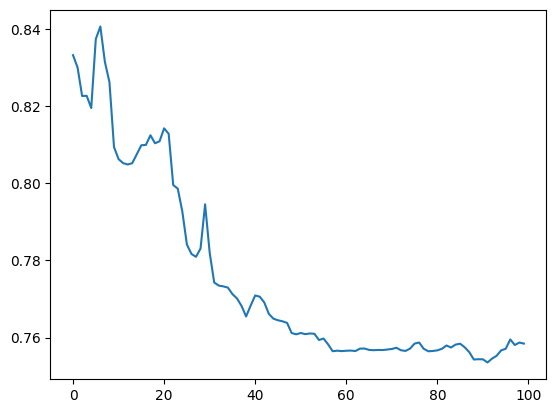

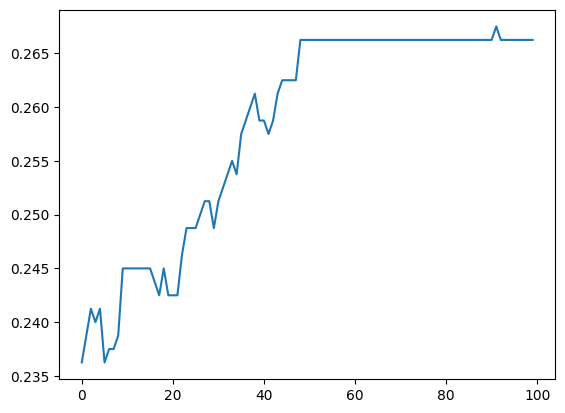

In [4]:
# This cell: low etas

np.random.seed(10)
import matplotlib.pyplot as plt
from tqdm import tqdm

def split_data(X,y_targets):
    split = int(0.8*len(X))
    trainX = X[:split]
    trainy = y_targets[:split]
    testX = X[split:]
    testy = y_targets[split:]
    return trainX, trainy, testX, testy

dataframe = pd.read_csv(
    'http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv',
    header=None
)

raw_data = dataframe.values
dataframe.head()
labels = raw_data[:1000, -1]
data = raw_data[:1000, 0:-1]

shuff = np.arange(len(labels))
np.random.shuffle(shuff)
data = data[shuff]
labels = labels[shuff]

U_train, y0_train, U_test, y0_test = split_data(data,labels)

eta = {'omega': 10, 'readout': [{'W': 10, 'b': 10}, {'W': 10, 'b': 10}]}

readout_params = init_mlp_params(0, [100,128,1])

network = RhythmicNetwork(
    dt=1,
    input_dims=1,
    spectral_radius=0.7,
    input_weight=1.0,
    average_degree_nodes=3,
    num_nodes=100,
    leakage=0.5
)
omega = network.get_natural_frequencies()

accs = []
costs = []
epochs = 100

all_params = {'omega':omega, 'readout': readout_params}

# iterate over training epochs
pert_key = 0
for epoch in range(epochs):
    epoch_costs = []
    epoch_accs = []

    #iterate over batchs
    for i in range(U_train.shape[0]):
        u = np.expand_dims(U_train[i], axis=0)
        y = y0_train[i]
    
        state, _ = rhythmic_forward(network, u, all_params["omega"])
        
        c0, correct = MGD_cost(all_params["readout"], state, y)
        epoch_accs.append(correct)
        
        gradient = init_grad(all_params)
        
        perts = get_perturbations(all_params,1e-6,pert_key)
        pert_key += 1
        all_params_pert = apply_perturbations(all_params,perts)

        state_pert, _ = rhythmic_forward(network, u, all_params_pert['omega'])
        # print(network.node_states[-1])
        # print(all_params["omega"], all_params_pert['omega'])
        
        c1, _ = MGD_cost(all_params_pert['readout'], state_pert, y)
        
        delta_c = c1 - c0
        # print(delta_c)
        
        gradient = collect_grad(all_params, delta_c, eta, gradient)
        # print(all_params["omega"])
        
        # update parameters
        all_params = MGD_update(all_params, gradient)
        # print(all_params["omega"])
        
        # reset gradient estimations
        gradient = init_grad(all_params)
        
        # record batched training cost
        epoch_costs.append(c0)
        # print(f"{i} - {c0}")
        
    # recored avg training cost
    accs.append(np.mean(epoch_accs))
    costs.append(np.mean(epoch_costs))
    # print(costs[-1], accs[-1])
    
plt.plot(costs)
plt.show()

plt.plot(accs)
plt.show()
    
    # # test model accuracy on unseen data
    # acc = compute_accuracy_binary(readout_params,s0_test,U_test,y0_test)
    # accs.append(acc)

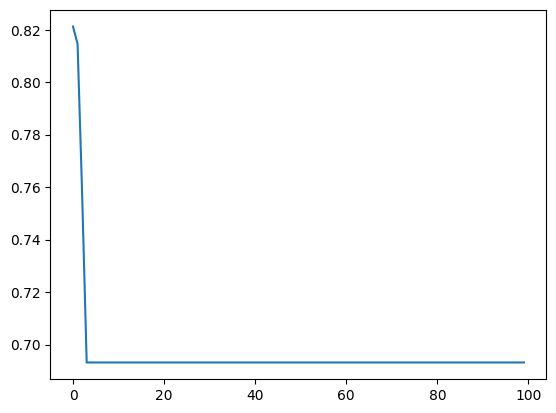

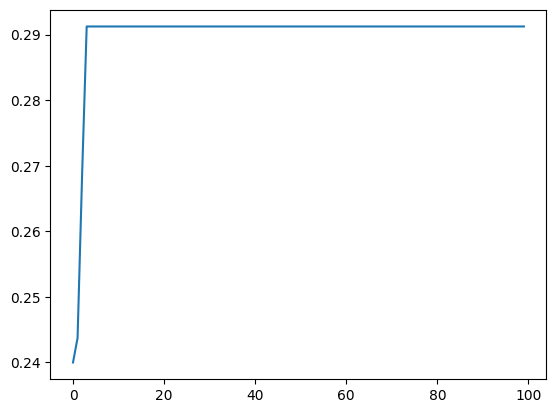

In [5]:
# This cell: medium etas

np.random.seed(10)
import matplotlib.pyplot as plt
from tqdm import tqdm

def split_data(X,y_targets):
    split = int(0.8*len(X))
    trainX = X[:split]
    trainy = y_targets[:split]
    testX = X[split:]
    testy = y_targets[split:]
    return trainX, trainy, testX, testy

dataframe = pd.read_csv(
    'http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv',
    header=None
)

raw_data = dataframe.values
dataframe.head()
labels = raw_data[:1000, -1]
data = raw_data[:1000, 0:-1]

shuff = np.arange(len(labels))
np.random.shuffle(shuff)
data = data[shuff]
labels = labels[shuff]

U_train, y0_train, U_test, y0_test = split_data(data,labels)

eta = {'omega': 100, 'readout': [{'W': 100, 'b': 100}, {'W': 100, 'b': 100}]}

readout_params = init_mlp_params(0, [100,128,1])

network = RhythmicNetwork(
    dt=1,
    input_dims=1,
    spectral_radius=0.7,
    input_weight=1.0,
    average_degree_nodes=3,
    num_nodes=100,
    leakage=0.5
)
omega = network.get_natural_frequencies()

accs = []
costs = []
epochs = 100

all_params = {'omega':omega, 'readout': readout_params}

# iterate over training epochs
pert_key = 0
for epoch in range(epochs):
    epoch_costs = []
    epoch_accs = []

    #iterate over batchs
    for i in range(U_train.shape[0]):
        u = np.expand_dims(U_train[i], axis=0)
        y = y0_train[i]
    
        state, _ = rhythmic_forward(network, u, all_params["omega"])
        
        c0, correct = MGD_cost(all_params["readout"], state, y)
        epoch_accs.append(correct)
        
        gradient = init_grad(all_params)
        
        perts = get_perturbations(all_params,1e-6,pert_key)
        pert_key += 1
        all_params_pert = apply_perturbations(all_params,perts)

        state_pert, _ = rhythmic_forward(network, u, all_params_pert['omega'])
        # print(network.node_states[-1])
        # print(all_params["omega"], all_params_pert['omega'])
        
        c1, _ = MGD_cost(all_params_pert['readout'], state_pert, y)
        
        delta_c = c1 - c0
        # print(delta_c)
        
        gradient = collect_grad(all_params, delta_c, eta, gradient)
        # print(all_params["omega"])
        
        # update parameters
        all_params = MGD_update(all_params, gradient)
        # print(all_params["omega"])
        
        # reset gradient estimations
        gradient = init_grad(all_params)
        
        # record batched training cost
        epoch_costs.append(c0)
        # print(f"{i} - {c0}")
        
    # recored avg training cost
    accs.append(np.mean(epoch_accs))
    costs.append(np.mean(epoch_costs))
    # print(costs[-1], accs[-1])
    
plt.plot(costs)
plt.show()

plt.plot(accs)
plt.show()
    
    # # test model accuracy on unseen data
    # acc = compute_accuracy_binary(readout_params,s0_test,U_test,y0_test)
    # accs.append(acc)

0.7928732 0.25625
1.446798 0.21625
0.84114665 0.25625
0.74866164 0.28375
1.8114742 0.23875
582983.2 0.24125
643217.06 0.24375
643217.06 0.24375
643217.06 0.24375
643217.06 0.24375
643217.06 0.24375
643217.06 0.24375
643217.06 0.24375
643217.06 0.24375
643217.06 0.24375
643217.06 0.24375
643217.06 0.24375
643217.06 0.24375
643217.06 0.24375
643217.06 0.24375
643217.06 0.24375
643217.06 0.24375
643217.06 0.24375
643217.06 0.24375
643217.06 0.24375


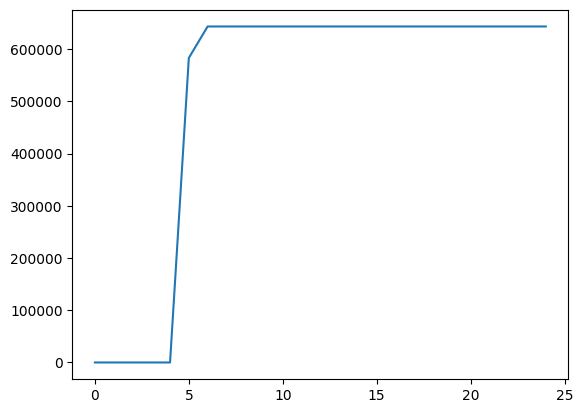

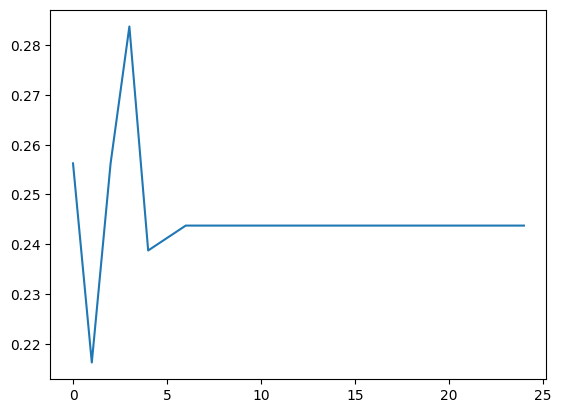

In [6]:
# This cell: higher etas

np.random.seed(10)
import matplotlib.pyplot as plt
from tqdm import tqdm

def split_data(X,y_targets):
    split = int(0.8*len(X))
    trainX = X[:split]
    trainy = y_targets[:split]
    testX = X[split:]
    testy = y_targets[split:]
    return trainX, trainy, testX, testy

dataframe = pd.read_csv(
    'http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv',
    header=None
)

raw_data = dataframe.values
dataframe.head()
labels = raw_data[:1000, -1]
data = raw_data[:1000, 0:-1]

shuff = np.arange(len(labels))
np.random.shuffle(shuff)
data = data[shuff]
labels = labels[shuff]

U_train, y0_train, U_test, y0_test = split_data(data,labels)

eta = {'omega': 1000, 'readout': [{'W': 1000, 'b': 1000}, {'W': 1000, 'b': 1000}]}

readout_params = init_mlp_params(0, [100,128,1])

network = RhythmicNetwork(
    dt=1,
    input_dims=1,
    spectral_radius=0.7,
    input_weight=1.0,
    average_degree_nodes=3,
    num_nodes=100,
    leakage=0.5
)
omega = network.get_natural_frequencies()

accs = []
costs = []
epochs = 25

all_params = {'omega':omega, 'readout': readout_params}

# iterate over training epochs
pert_key = 0
for epoch in range(epochs):
    epoch_costs = []
    epoch_accs = []

    #iterate over batchs
    for i in range(U_train.shape[0]):
        u = np.expand_dims(U_train[i], axis=0)
        y = y0_train[i]
    
        state, _ = rhythmic_forward(network, u, all_params["omega"])
        
        c0, correct = MGD_cost(all_params["readout"], state, y)
        epoch_accs.append(correct)
        
        gradient = init_grad(all_params)
        
        perts = get_perturbations(all_params,1e-6,pert_key)
        pert_key += 1
        all_params_pert = apply_perturbations(all_params,perts)

        state_pert, _ = rhythmic_forward(network, u, all_params_pert['omega'])
        # print(network.node_states[-1])
        # print(all_params["omega"], all_params_pert['omega'])
        
        c1, _ = MGD_cost(all_params_pert['readout'], state_pert, y)
        
        delta_c = c1 - c0
        # print(delta_c)
        
        gradient = collect_grad(all_params, delta_c, eta, gradient)
        # print(all_params["omega"])
        
        # update parameters
        all_params = MGD_update(all_params, gradient)
        # print(all_params["omega"])
        
        # reset gradient estimations
        gradient = init_grad(all_params)
        
        # record batched training cost
        epoch_costs.append(c0)
        # print(f"{i} - {c0}")
        
    # recored avg training cost
    accs.append(np.mean(epoch_accs))
    costs.append(np.mean(epoch_costs))
    print(costs[-1], accs[-1])
    
plt.plot(costs)
plt.show()

plt.plot(accs)
plt.show()
    
    # # test model accuracy on unseen data
    # acc = compute_accuracy_binary(readout_params,s0_test,U_test,y0_test)
    # accs.append(acc)

161151.23
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e+06
2.5652058e

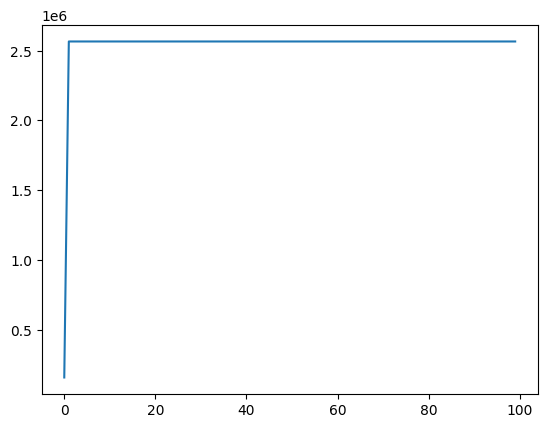

In [7]:
# This cell: also setting epsilons

readout_params = init_mlp_params(0, [100,128,1])

network = RhythmicNetwork(
    dt=1,
    input_dims=1,
    spectral_radius=0.7,
    input_weight=1.0,
    average_degree_nodes=3,
    num_nodes=100,
    leakage=0.5
)
omega = network.get_natural_frequencies()
eps = np.asarray([network.epsilon1, network.epsilon2])

accs = []
costs = []
epochs = 100

all_params = {'omega':omega, 'readout': readout_params, "eps": eps}
eta = {'omega': 10, 'readout': [{'W': 1, 'b': 1}, {'W': 1, 'b': 1}], 'eps': 0.0001}

# iterate over training epochs
pert_key = 0
for epoch in range(epochs):
    epoch_costs = []

    #iterate over batchs
    for i in range(U_train.shape[0]):
        u = np.expand_dims(U_train[i], axis=0)
        y = y0_train[i]
    
        state, _ = rhythmic_forward(network, u, all_params["omega"], eps=all_params["eps"])
        
        c0, correct = MGD_cost(all_params["readout"], state, y)
        
        gradient = init_grad(all_params)
        
        perts = get_perturbations(all_params,1e-6,pert_key)
        pert_key += 1
        all_params_pert = apply_perturbations(all_params,perts)

        state_pert, _ = rhythmic_forward(network, u, all_params_pert["omega"], eps=all_params_pert["eps"])
        # print(network.node_states[-1])
        # print(all_params["omega"], all_params_pert['omega'])
        
        c1, _ = MGD_cost(all_params_pert['readout'], state_pert, y)
        
        delta_c = c1 - c0
        
        gradient = collect_grad(all_params, delta_c, eta, gradient)
        
        # update parameters
        all_params = MGD_update(all_params, gradient)
        
        # reset gradient estimations
        gradient = init_grad(all_params)
        
        # record batched training cost
        epoch_costs.append(c0)
        # print(f"{i} - {c0}")
        
    # recored avg training cost
    costs.append(np.mean(epoch_costs))
    print(np.mean(epoch_costs))
plt.plot(costs)
plt.show()
    
    # # test model accuracy on unseen data
    # acc = compute_accuracy_binary(readout_params,s0_test,U_test,y0_test)
    # accs.append(acc)

0.7895604
0.72463626
0.7147052
0.7155339
0.7096878
0.69676435
0.69467425
0.69409966
0.6942782
0.69456863
0.69441026
0.6939714
0.6938277
0.69402015
0.6941882
0.69432753
0.69412214
0.6939439
0.6939242
0.6939432
0.6940251
0.69418657
0.6938961
0.6936487
0.69371307
0.6938579
0.6939577
0.69459915
0.6946074
0.69425017
0.6938977
0.69409025
0.6943428
0.69402957
0.6939882
0.69452256
0.6941357
0.6937615
0.69356245
0.6934864
0.69349563
0.69351006
0.693497
0.6934619
0.6933762
0.6932902
0.6932585
0.69324934
0.69324404
0.69324666
0.69326437
0.6933071
0.6933087
0.69336075
0.69334304
0.6933322
0.6933085
0.69328696
0.69325274
0.6932405
0.69325155
0.6932325
0.69321525
0.69323516
0.6932643
0.69324934
0.6932387
0.69326574
0.6932578
0.69324404
0.69325036
0.69325376
0.69324785
0.6933157
0.6933902
0.69334686
0.6932949
0.6932913
0.69324744
0.69322896
0.69320506
0.6932024
0.6931923
0.69318044
0.6931834
0.69319785
0.6932104
0.6932145
0.6931978
0.6932008
0.6932097
0.6932113
0.693215
0.693208
0.69319206
0.6931831


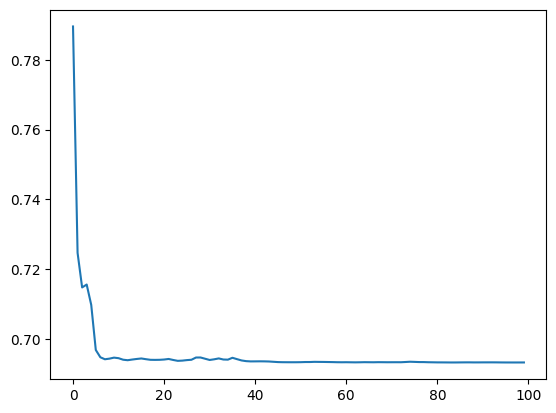

In [8]:
# This cell: no omega setting

readout_params = init_mlp_params(0, [100,128,1])

network = RhythmicNetwork(
    dt=1,
    input_dims=1,
    spectral_radius=0.7,
    input_weight=1.0,
    average_degree_nodes=3,
    num_nodes=100,
    leakage=0.5
)
omega = network.get_natural_frequencies()

accs = []
costs = []
epochs = 100

all_params = {'readout': readout_params}
eta = {'readout': [{'W': 10_000, 'b': 10_000}, {'W': 10000, 'b': 10_000}]}

# iterate over training epochs
pert_key = 0
for epoch in range(epochs):
    epoch_costs = []

    #iterate over batchs
    for i in range(U_train.shape[0]):
        u = np.expand_dims(U_train[i], axis=0)
        y = y0_train[i]
    
        state, _ = rhythmic_forward(network, u, omega) # Not trying to learn omega here
        
        c0, correct = MGD_cost(all_params["readout"], state, y)
        
        gradient = init_grad(all_params)
        
        perts = get_perturbations(all_params,1e-6,pert_key)
        pert_key += 1
        all_params_pert = apply_perturbations(all_params,perts)

        state_pert, _ = rhythmic_forward(network, u, omega)  # Not trying to learn omega here
        # print(network.node_states[-1])
        # print(all_params["omega"], all_params_pert['omega'])
        
        c1, _ = MGD_cost(all_params_pert['readout'], state_pert, y)
        
        delta_c = c1 - c0
        
        gradient = collect_grad(all_params, delta_c, eta, gradient)
        
        # update parameters
        all_params = MGD_update(all_params, gradient)
        
        # reset gradient estimations
        gradient = init_grad(all_params)
        
        # record batched training cost
        epoch_costs.append(c0)
        # print(f"{i} - {c0}")
        
    # recored avg training cost
    costs.append(np.mean(epoch_costs))
    print(np.mean(epoch_costs))
plt.plot(costs)
plt.show()
    
    # # test model accuracy on unseen data
    # acc = compute_accuracy_binary(readout_params,s0_test,U_test,y0_test)
    # accs.append(acc)